In [196]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
import glob 
import re


Tests run at:
- 10 V Floating Potential + 1.7 V Heating Potential (0.98A)
- 0.0 V DC In/Ap2
- -3.0 V Spacers
- -6.0 V DC Out/Ap3
- $\approx 1.4E-5$ Gauge
- -2400 V Detector Bias


In [197]:
def parse_rf_filename(filepath):
    basename = filepath.split("/")[-1]
    match = re.match(r"RF(\d+)_(\d+)(?:_(\d+))?\.mpa$", basename)
    if match is None:
        return None
    vpp = int(match.group(1))
    freq_khz = int(match.group(2))
    run = int(match.group(3)) if match.group(3) else 1
    return vpp, freq_khz, run

def read_mpa_file(filepath):
    realtime = None
    totalsum = None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum

def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc

rf_files = [f for f in glob.glob("RFPCB/RF*.mpa") if "Noise" not in f]

rf_runs = []
for filepath in rf_files:
    parsed = parse_rf_filename(filepath)
    if parsed is None:
        continue
    vpp, freq_khz, run = parsed
    rf_runs.append({"filepath": filepath, "vpp": vpp, "freq_khz": freq_khz, "run": run})

rf_runs_df = pd.DataFrame(rf_runs).sort_values(["freq_khz", "vpp", "run"]).reset_index(drop=True)

rf_runs_df["rate_hz"], rf_runs_df["rate_unc_hz"] = zip(
    *rf_runs_df["filepath"].apply(get_rate_and_uncertainty)
)

In [198]:
potassium_mass = 39.0983  # g/mol
rubidium_mass = 85.4678  # g/mol
cesium_mass = 132.90545  # g/mol

e = 1.602176634e-19  # elementary charge in Coulombs
u = 1.66053906660e-27  # atomic mass unit in kg

r_0 = 1/2*np.sqrt((0.5 * (6.60 + 6.55))**2 + (0.5 * (6.60 + 6.72))**2)
print(r_0)

4.679375626085172


In [199]:
run1_df = rf_runs_df[rf_runs_df["run"] == 1].copy()

In [200]:
def q_val(m, f, r, vpp):
    m_kg = m * u  # convert mass from g/mol to kg
    V0 = vpp / 2  # peak voltage in volts
    omega = 2 * np.pi * f * 1e3  # angular frequency in rad/s
    r_0_m = r/1000  # convert r from mm to meters
    q = 4 * e * V0 / (m_kg * omega**2 * r_0_m**2)
    return q


In [201]:
species = {
    "Cesium": cesium_mass,
    "Rubidium": rubidium_mass,
    "Potassium": potassium_mass
}

q_tables = {}

for name, mass in species.items():
    table = rf_runs_df[["freq_khz", "vpp"]].copy()
    table['q'] = rf_runs_df.apply(lambda row: q_val(mass, row['freq_khz'], r_0, row['vpp']), axis=1)
    table = table.sort_values(["freq_khz", "vpp"]).reset_index(drop=True)
    q_tables[name] = table

def make_titled_table(name, mass, rf_runs_df, r_0):
    table = rf_runs_df[["freq_khz", "vpp"]].copy()
    table["q"] = rf_runs_df.apply(
        lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]),
        axis=1
    )
    table = table.sort_values(["freq_khz", "vpp"]).reset_index(drop=True)

    # Build a two-level column header: top level is the title, spans all columns
    table.columns = pd.MultiIndex.from_product([[f"{name} q-values"], table.columns])
    return table

cesium_table = make_titled_table("Cesium", cesium_mass, rf_runs_df, r_0).style.hide(axis="index")
potassium_table = make_titled_table("Potassium", potassium_mass, rf_runs_df, r_0).style.hide(axis="index")
rubidium_table = make_titled_table("Rubidium", rubidium_mass, rf_runs_df, r_0).style.hide(axis="index")

run_config = {
    1: {"label": "Baseline Original", "float_v": 10, "delta_v": 6},
    2: {"label": "Baseline", "float_v": 10, "delta_v": 6},
    3: {"label": "ΔV=3V (Float=10V)", "float_v": 10, "delta_v": 3},
    4: {"label": "Float=5V (ΔV=6V)", "float_v": 5, "delta_v": 6},
    5: {"label": "Combined (Float=5V, ΔV=3V)", "float_v": 5, "delta_v": 3},
}

rf_runs_df["config_label"] = rf_runs_df["run"].map(lambda r: run_config[r]["label"])

In [202]:
rubidium_table

In [203]:
cesium_table

In [204]:
run1_df = rf_runs_df[rf_runs_df["run"] == 1].copy()

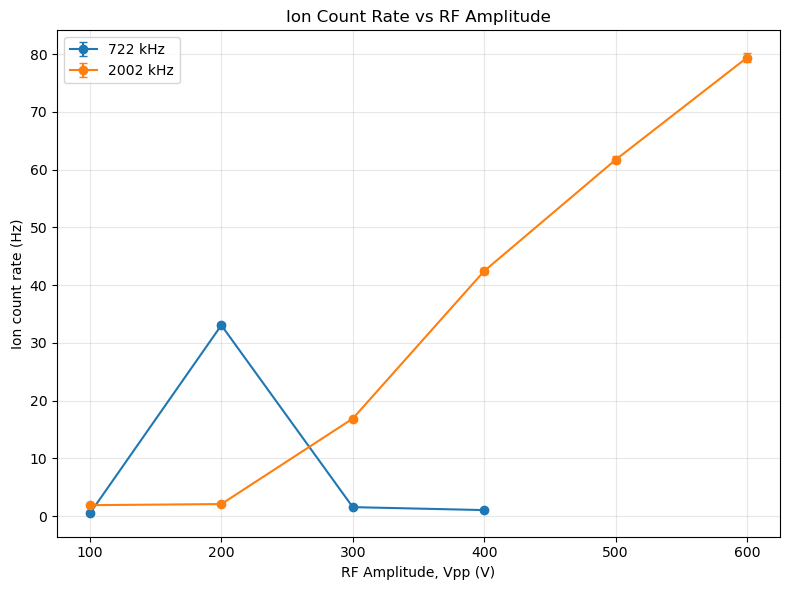

In [205]:
fig, ax = plt.subplots(figsize=(8, 6))

for freq_khz, group in run1_df.groupby("freq_khz"):
    group = group.sort_values("vpp")
    ax.errorbar(
        group["vpp"], group["rate_hz"], yerr=group["rate_unc_hz"],
        marker="o", capsize=3, label=f"{freq_khz} kHz"
    )


#ax.set_yscale("log")
ax.set_xlabel("RF Amplitude, Vpp (V)")
ax.set_ylabel("Ion count rate (Hz)")
ax.set_title("Ion Count Rate vs RF Amplitude")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

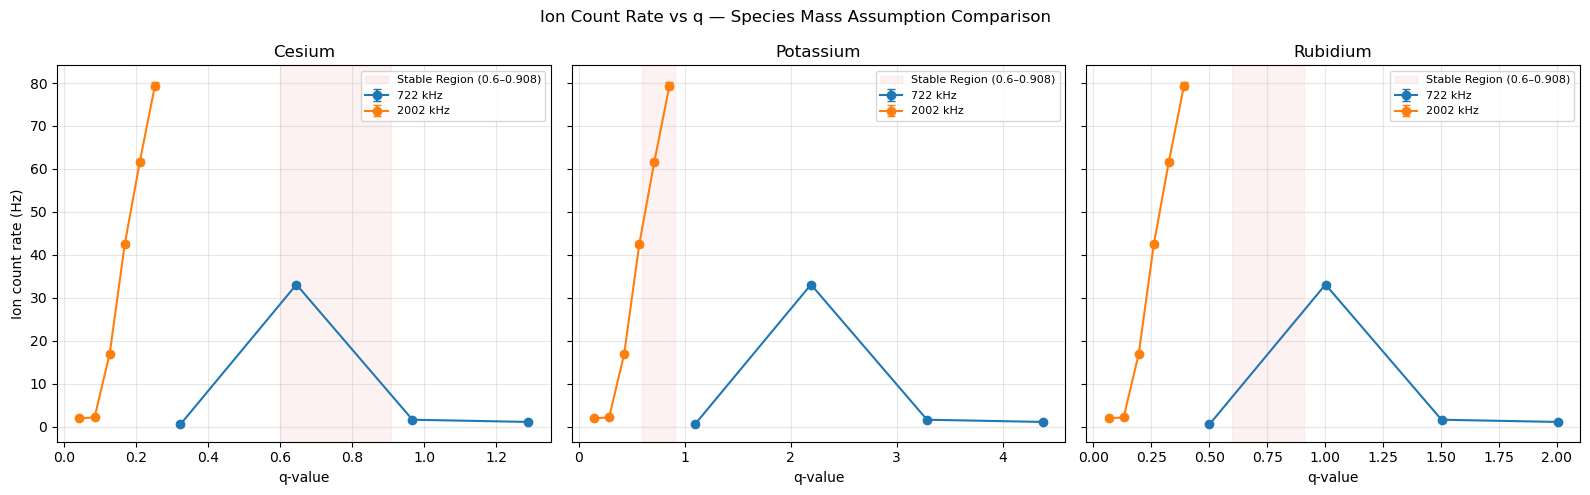

In [206]:
def plot_species(ax, name, mass, data_df, r_0):
    plot_df = data_df[["freq_khz", "vpp", "rate_hz", "rate_unc_hz"]].copy()
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]),
        axis=1
    )

    ax.axvspan(0.6, 0.908, color='lightcoral', alpha=0.1, label='Stable Region (0.6–0.908)')

    for freq_khz, group in plot_df.groupby("freq_khz"):
        group = group.sort_values("q")
        ax.errorbar(
            group["q"], group["rate_hz"], yerr=group["rate_unc_hz"],
            marker="o", capsize=3, label=f"{freq_khz} kHz"
        )

    ax.set_xlabel("q-value")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

plot_species(axes[0], "Cesium", cesium_mass, run1_df, r_0)
plot_species(axes[1], "Potassium", potassium_mass, run1_df, r_0)
plot_species(axes[2], "Rubidium", rubidium_mass, run1_df, r_0)

axes[0].set_ylabel("Ion count rate (Hz)")
fig.suptitle("Ion Count Rate vs q — Species Mass Assumption Comparison")
plt.tight_layout()
plt.show()

In [207]:
# Run two, more refined search of 722 KHz test:

v_in = [1.2, 1.4, 1.6, 2.5, 2.8, 3.0, 3.2, 3.4, 3.6, 3.9, 4.2]

In [208]:
run2_df = rf_runs_df[(rf_runs_df["run"] == 2)].copy()
run2_df

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label
14,RFPCB/RF100_722_2.mpa,100,722,2,1.092940,0.085344,Baseline
18,RFPCB/RF114_722_2.mpa,114,722,2,2.143566,0.119456,Baseline
23,RFPCB/RF128_722_2.mpa,128,722,2,30.848860,0.453317,Baseline
26,RFPCB/RF148_722_2.mpa,148,722,2,36.881917,0.495562,Baseline
29,RFPCB/RF164_722_2.mpa,164,722,2,41.530076,0.526034,Baseline
32,RFPCB/RF186_722_2.mpa,186,722,2,45.365798,0.549818,Baseline
36,RFPCB/RF200_722_2.mpa,200,722,2,42.514615,0.532348,Baseline
40,RFPCB/RF224_722_2.mpa,224,722,2,38.920879,0.509303,Baseline
43,RFPCB/RF240_722_2.mpa,240,722,2,20.562727,0.370094,Baseline
46,RFPCB/RF260_722_2.mpa,260,722,2,2.450197,0.127725,Baseline


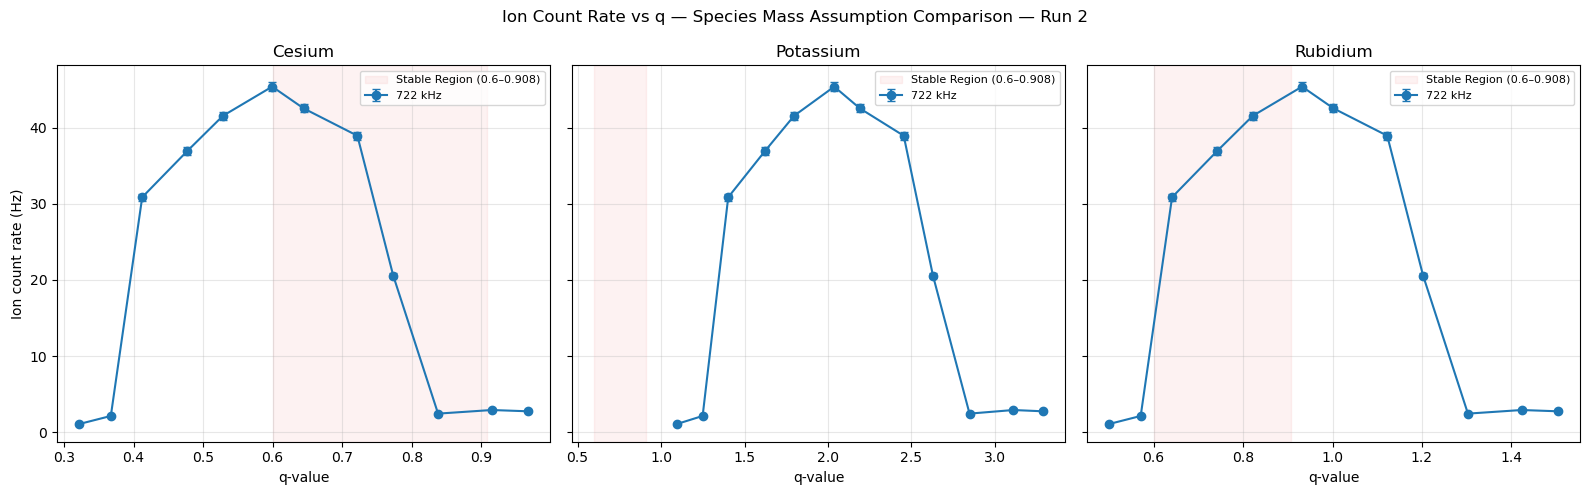

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

plot_species(axes[0], "Cesium", cesium_mass, run2_df, r_0)
plot_species(axes[1], "Potassium", potassium_mass, run2_df, r_0)
plot_species(axes[2], "Rubidium", rubidium_mass, run2_df, r_0)

axes[0].set_ylabel("Ion count rate (Hz)")
fig.suptitle("Ion Count Rate vs q — Species Mass Assumption Comparison — Run 2")
plt.tight_layout()
plt.show()

In [210]:
def compute_resolving_power_mc(mass, run_df, r_0, freq_khz=722, n_trials=2000, seed=None):
    """
    Monte Carlo uncertainty on resolving power: resample each rate point
    within its Poisson uncertainty, recompute FWHM/resolving power each time.
    """
    rng = np.random.default_rng(seed)

    df = run_df[run_df["freq_khz"] == freq_khz].copy()
    df["q"] = df.apply(lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
    df = df.sort_values("q").reset_index(drop=True)

    q_arr = df["q"].values
    rate_arr = df["rate_hz"].values
    rate_unc_arr = df["rate_unc_hz"].values

    resolving_powers = []
    q_peaks = []
    fwhms = []

    for _ in range(n_trials):
        # Resample each point from a Gaussian around its measured rate
        sampled_rate = rng.normal(rate_arr, rate_unc_arr)
        sampled_rate = np.clip(sampled_rate, 0, None)  # rates can't go negative

        peak_idx = np.argmax(sampled_rate)
        q_peak = q_arr[peak_idx]
        rate_peak = sampled_rate[peak_idx]
        half_max = rate_peak / 2

        rising_q = q_arr[:peak_idx + 1]
        rising_rate = sampled_rate[:peak_idx + 1]
        falling_q = q_arr[peak_idx:]
        falling_rate = sampled_rate[peak_idx:]

        try:
            q_left = np.interp(half_max, rising_rate, rising_q)
            q_right = np.interp(half_max, falling_rate[::-1], falling_q[::-1])
        except Exception:
            continue  # skip degenerate trials (e.g. non-monotonic after resampling)

        fwhm_q = q_right - q_left
        if fwhm_q <= 0 or q_peak <= 0:
            continue  # skip unphysical trials

        delta_m = (fwhm_q / q_peak) * mass
        resolving_powers.append(mass / delta_m)
        q_peaks.append(q_peak)
        fwhms.append(fwhm_q)

    resolving_powers = np.array(resolving_powers)
    n_valid = len(resolving_powers)

    return {
        "resolving_power_mean": np.mean(resolving_powers),
        "resolving_power_std": np.std(resolving_powers),
        "resolving_power_median": np.median(resolving_powers),
        "n_valid_trials": n_valid,
        "n_total_trials": n_trials,
    }

In [211]:
runs_to_compare = [2, 3, 4, 5]  # excludes original crude baseline (run 1)

summary_rows = []
for run_num in runs_to_compare:
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    if run_df.empty:
        continue
    meta = run_config[run_num]
    n_points = len(run_df[run_df["freq_khz"] == 722])
    mc_result = compute_resolving_power_mc(rubidium_mass, run_df, r_0, freq_khz=722, n_trials=2000, seed=42)
    summary_rows.append({
        "run": run_num,
        "config": meta["label"],
        "n_points": n_points,
        "resolving_power": mc_result["resolving_power_mean"],
        "resolving_power_err": mc_result["resolving_power_std"],
        "note": "PARTIAL — missing 2nd half" if run_num == 5 else ""
    })


summary_df = pd.DataFrame(summary_rows)
summary_df

,run,config,n_points,resolving_power,resolving_power_err,note
0,2,Baseline,12,1.629891,0.007124,
1,3,ΔV=3V (Float=10V),18,0.970350,0.018637,
2,4,Float=5V (ΔV=6V),16,1.486975,0.134271,
3,5,"Combined (Float=5V, ΔV=3V)",7,2.894930,0.007712,PARTIAL — missing 2nd half


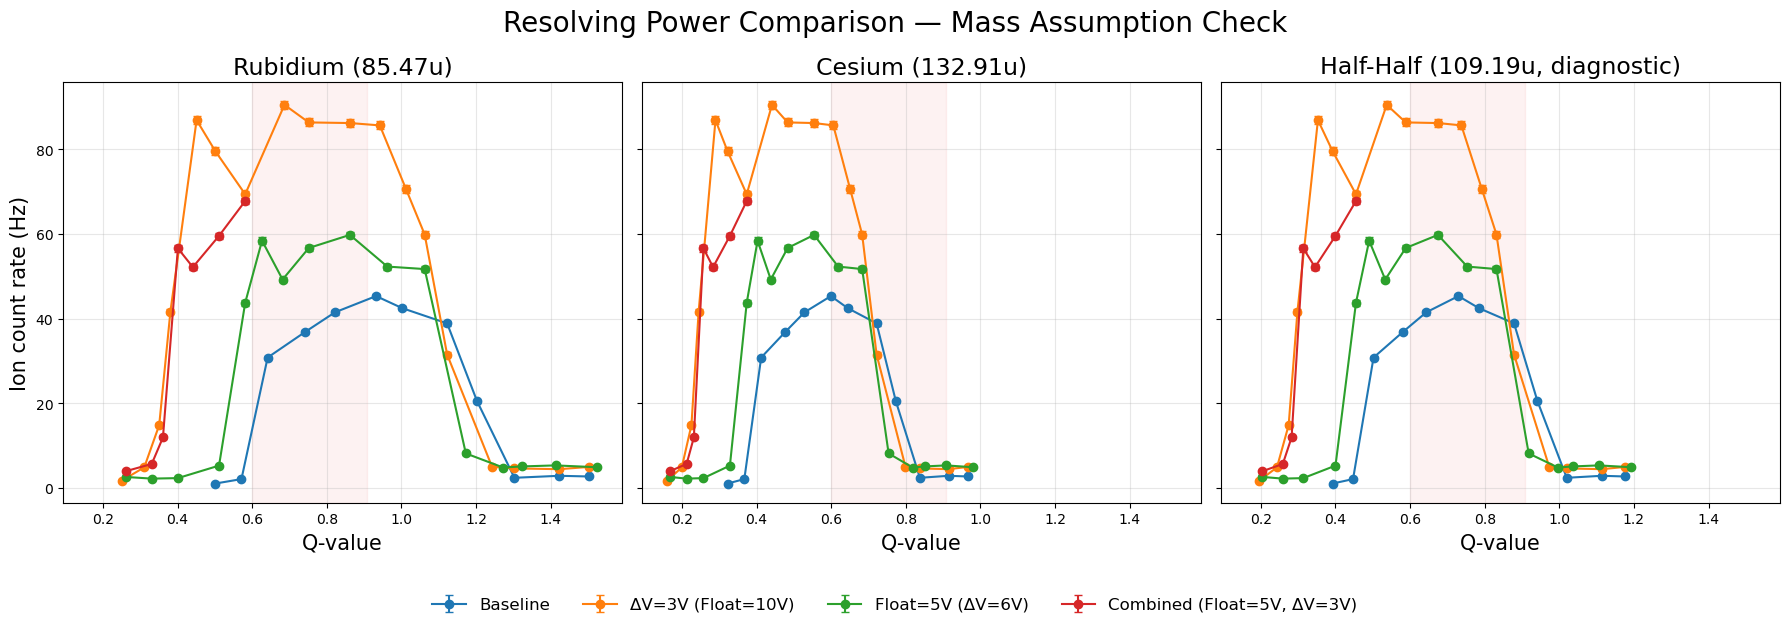

In [219]:
mixed_mass = (rubidium_mass + cesium_mass) / 2

mass_panels = {
    "Rubidium (85.47u)": rubidium_mass,
    "Cesium (132.91u)": cesium_mass,
    "Half-Half (109.19u, diagnostic)": mixed_mass,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

all_q_values = []
for panel_name, mass in mass_panels.items():
    for run_num in runs_to_compare:
        run_df = rf_runs_df[rf_runs_df["run"] == run_num]
        if run_df.empty:
            continue
        plot_df = run_df[run_df["freq_khz"] == 722].copy()
        q_vals = plot_df.apply(lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
        all_q_values.extend(q_vals.tolist())

q_min, q_max = min(all_q_values), max(all_q_values)
q_pad = (q_max - q_min) * 0.05

for ax, (panel_name, mass) in zip(axes, mass_panels.items()):
    ax.axvspan(0.6, 0.908, color='lightcoral', alpha=0.1)
    for run_num in runs_to_compare:
        run_df = rf_runs_df[rf_runs_df["run"] == run_num]
        if run_df.empty:
            continue
        meta = run_config[run_num]
        plot_df = run_df[run_df["freq_khz"] == 722].copy()
        plot_df["q"] = plot_df.apply(lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
        plot_df = plot_df.sort_values("q")
        ax.errorbar(plot_df["q"], plot_df["rate_hz"], yerr=plot_df["rate_unc_hz"],
                    marker="o", capsize=3, label=meta["label"])
    ax.set_xlim(q_min - q_pad, q_max + q_pad)
    ax.set_xlabel("Q-value", fontsize=15)
    ax.set_title(panel_name, fontsize = 17)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Ion count rate (Hz)", fontsize = 15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=len(labels), fontsize=12, frameon=False)

fig.suptitle("Resolving Power Comparison — Mass Assumption Check", fontsize = 20)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()